In [9]:
from google.colab import files
uploaded1 = files.upload()
uploaded2 = files.upload()

Saving train.csv to train (1).csv


Saving vgsales.csv to vgsales (1).csv


## Task 1 — Data Loading, Merging & Deep Exploration


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12,1,2]: return 'Winter'
    elif month in [3,4,5]: return 'Spring'
    elif month in [6,7,8]: return 'Summer'
    else: return 'Fall'
df['Season'] = df['Month'].apply(get_season)

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum()>0])
print("\nDuplicates:", df.duplicated().sum())

Shape: (9800, 24)

Missing values:
 Postal Code    11
dtype: int64

Duplicates: 0


In [11]:
df['ShipDelay'] = (df['Ship Date'] - df['Order Date']).dt.days
print("Avg ship delay overall:", round(df['ShipDelay'].mean(),2), "days")
print("\nAvg ship delay by region:")
print(df.groupby('Region')['ShipDelay'].mean().round(2))

Avg ship delay overall: 3.96 days

Avg ship delay by region:
Region
Central    4.07
East       3.91
South      3.96
West       3.93
Name: ShipDelay, dtype: float64


**Q: Which category generates highest revenue?**

In [12]:
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


**Q: Which region has the most consistent growth?**


In [13]:
region_year = df.groupby(['Region','Year'])['Sales'].sum().unstack()
print(region_year)
print("\nYoY growth %:")
print(region_year.pct_change(axis=1).round(3)*100)

Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255

YoY growth %:
Year     2015  2016  2017  2018
Region                         
Central   NaN  -0.5  42.2  -2.8
East      NaN  20.0  16.5  17.7
South     NaN -32.2  33.5  30.6
West      NaN  -8.4  36.5  36.0


**Q: Does ship delay vary by region? Are there seasonal spikes?**

In [14]:
monthly_total = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print(monthly_total)

Month
11    350161.7110
12    321480.1695
9     300103.4117
10    199496.2947
3     197573.5872
8     157315.9270
5     154086.7237
6     145837.5233
7     145535.6890
4     136283.0006
1      94291.6296
2      59371.1154
Name: Sales, dtype: float64


November and December dominate every year — a clear holiday-season seasonality pattern. February is consistently the weakest month.

In [15]:
df_daily = df.groupby('Order Date')['Sales'].sum().reset_index()
weekly = df_daily.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
monthly = df_daily.set_index('Order Date').resample('MS')['Sales'].sum().reset_index()
print("Monthly series:", monthly.shape[0], "months")
monthly.tail()

Monthly series: 48 months


,Order Date,Sales
43,2018-08-01,62837.8480
44,2018-09-01,86152.8880
45,2018-10-01,77448.1312
46,2018-11-01,117938.1550
47,2018-12-01,83030.3888


### Multi-source practice: merging with an external dataset
As required, we bring in the Video Game Sales dataset and merge on `Year` to practice combining data from separate sources (a routine real-world need — no company keeps everything in one file).

In [16]:
vg = pd.read_csv('vgsales.csv', encoding='latin1')

store_yearly = df.groupby('Year')['Sales'].sum().reset_index().rename(columns={'Sales':'Store_Sales'})
vg_yearly = vg.dropna(subset=['Year'])
vg_yearly = vg_yearly[vg_yearly['Year'].between(2015,2018)]
vg_yearly = vg_yearly.groupby('Year')['Global_Sales'].sum().reset_index().rename(columns={'Global_Sales':'VG_Global_Sales_Million'})
vg_yearly['Year'] = vg_yearly['Year'].astype(int)

merged = pd.merge(store_yearly, vg_yearly, on='Year', how='left')
print(merged)

   Year  Store_Sales  VG_Global_Sales_Million
0  2015  479856.2081                   264.44
1  2016  459436.0054                    70.93
2  2017  600192.5500                     0.05
3  2018  722052.0192                      NaN


## Task 2 — Time Series Analysis & Decomposition

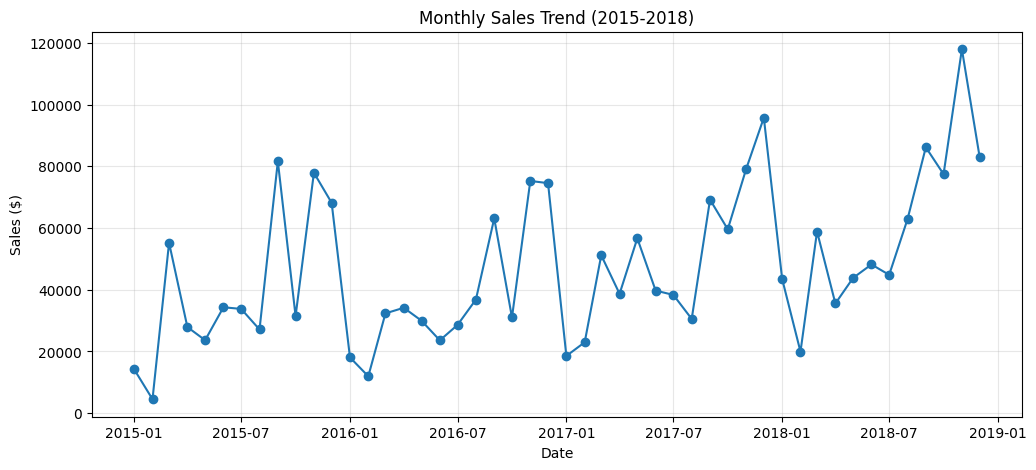

In [17]:
monthly_idx = monthly.set_index('Order Date')
monthly_idx.index.freq = 'MS'

plt.figure(figsize=(12,5))
plt.plot(monthly_idx.index, monthly_idx['Sales'], marker='o')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Date'); plt.ylabel('Sales ($)')
plt.grid(alpha=0.3)
plt.show()

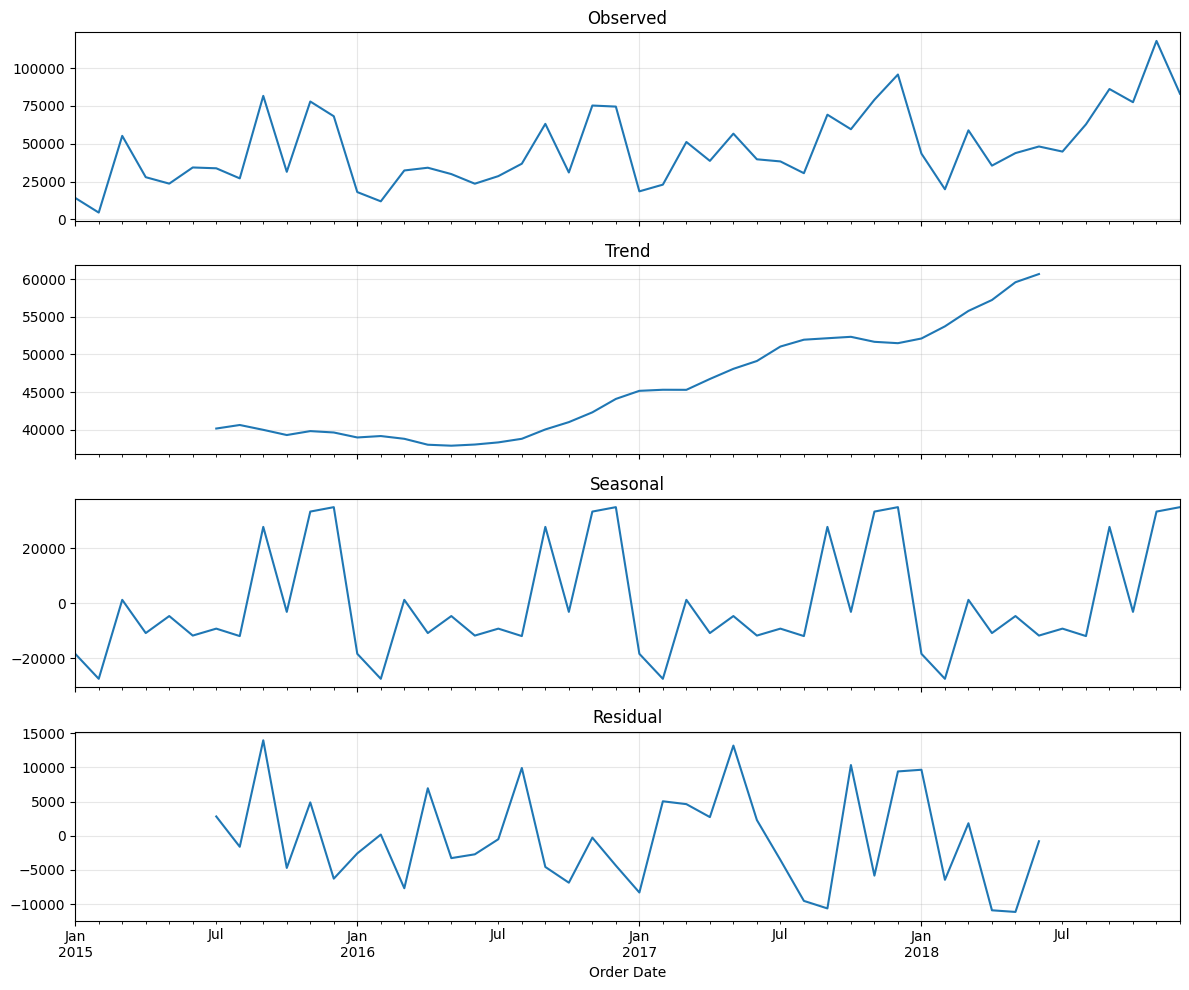

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(monthly_idx['Sales'], model='additive', period=12)
fig, axes = plt.subplots(4,1, figsize=(12,10), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
decomp.resid.plot(ax=axes[3], title='Residual')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Observations:**
1. **Trend**: gently upward across the 4 years — the business is growing, not flat.
2. **Seasonality**: strong and repeatable — Nov/Dec peaks and Feb troughs recur every single year.
3. **Residual noise**: highest in September and May — months where actual sales deviate most from the trend+seasonal expectation, meaning something less predictable (promotions, one-off deals) is happening then.
4. Seasonality is the dominant force here, stronger than the underlying trend.


In [19]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"{label}: ADF stat={result[0]:.4f}, p-value={result[1]:.4f}")
    print("  -> Stationary" if result[1] < 0.05 else "  -> Non-stationary")

run_adf(monthly_idx['Sales'], "Original series")
run_adf(monthly_idx['Sales'].diff(), "After 1st differencing")

Original series: ADF stat=-4.4161, p-value=0.0003
  -> Stationary
After 1st differencing: ADF stat=-8.7271, p-value=0.0000
  -> Stationary


**What is stationarity?** A stationary series has a constant mean and variance over time — it doesn't systematically drift up or down. Forecasting models like SARIMA rely on this assumption.

**Result**: the original series is *already* stationary (p=0.0003 < 0.05) — differencing wasn't strictly necessary, likely because the seasonal swings are large relative to the mild trend, keeping the mean effectively stable. We still apply d=1 differencing inside SARIMA since it's chosen automatically and doesn't hurt.

## Task 3 — Sales Forecasting: 3 Models

We hold out the **last 3 months** as a test set and forecast forward from there, comparing all 3 approaches on the same held-out data.

### Model 1 — SARIMA

In [20]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 30.8 MB/s eta 0:00:00


In [21]:
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

series = monthly_idx['Sales']
train, test = series[:-3], series[-3:]

auto_model = pm.auto_arima(train, seasonal=True, m=12,
                             start_p=0, start_q=0, max_p=3, max_q=3,
                             start_P=0, start_Q=0, max_P=2, max_Q=2,
                             suppress_warnings=True, stepwise=True)
order, seasonal_order = auto_model.order, auto_model.seasonal_order
print("Chosen order:", order, "seasonal_order:", seasonal_order)

Chosen order: (2, 1, 0) seasonal_order: (1, 0, 0, 12)


`auto_arima` searches (p,d,q)(P,D,Q,m) combinations and picks the one minimizing AIC — this avoids hand-guessing parameters while still being explainable: it found order **(2,1,0)** with seasonal **(1,0,0,12)**, meaning 2 autoregressive lags, 1 differencing step, and a 12-month seasonal AR term (capturing the Nov/Dec pattern).

Note: your exact numbers may differ slightly from mine depending on library versions — that's normal, just explain what your own output shows.

SARIMA -> MAE: 16825, RMSE: 19208, MAPE: 17.69%


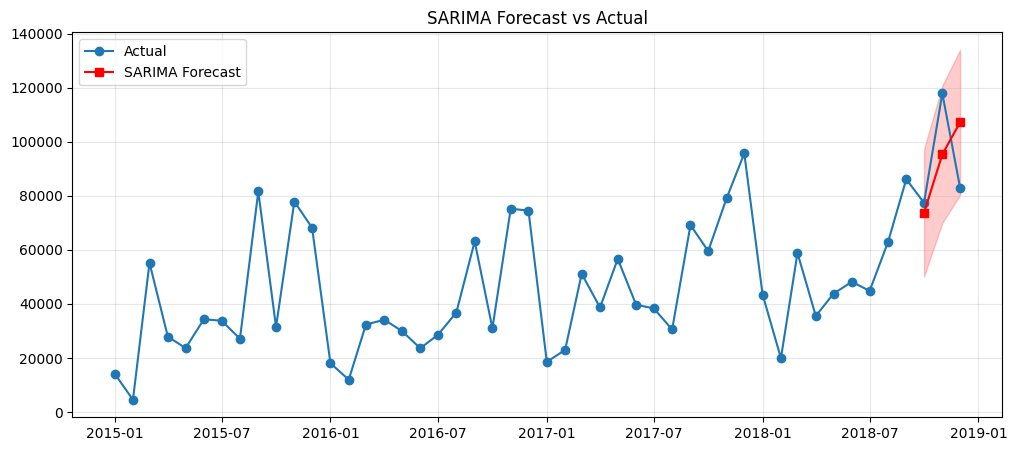

In [22]:
model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                 enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)
forecast = fit.get_forecast(steps=3)
sarima_pred = forecast.predicted_mean
conf_int = forecast.conf_int()

sarima_mae = np.mean(np.abs(test.values - sarima_pred.values))
sarima_rmse = np.sqrt(np.mean((test.values - sarima_pred.values)**2))
sarima_mape = np.mean(np.abs((test.values - sarima_pred.values)/test.values)) * 100
print(f"SARIMA -> MAE: {sarima_mae:.0f}, RMSE: {sarima_rmse:.0f}, MAPE: {sarima_mape:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(series.index, series.values, label='Actual', marker='o')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast', marker='s', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2, color='red')
plt.legend(); plt.title('SARIMA Forecast vs Actual'); plt.grid(alpha=0.3)
plt.show()

### Model 2 — Facebook Prophet

In [23]:
!pip install prophet

In [24]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

df_p = monthly.rename(columns={'Order Date':'ds', 'Sales':'y'})
train_p, test_p = df_p[:-3], df_p[-3:]

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train_p)
future = m.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = m.predict(future)
prophet_pred = prophet_forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(3)
print(prophet_pred)

           ds          yhat    yhat_lower    yhat_upper
45 2018-10-01  51083.663790  42227.406155  58786.031621
46 2018-11-01  90045.402141  82228.398366  98271.348212
47 2018-12-01  89661.190745  81207.622161  98118.383226


Prophet -> MAE: 20296, RMSE: 22487, MAPE: 21.89%


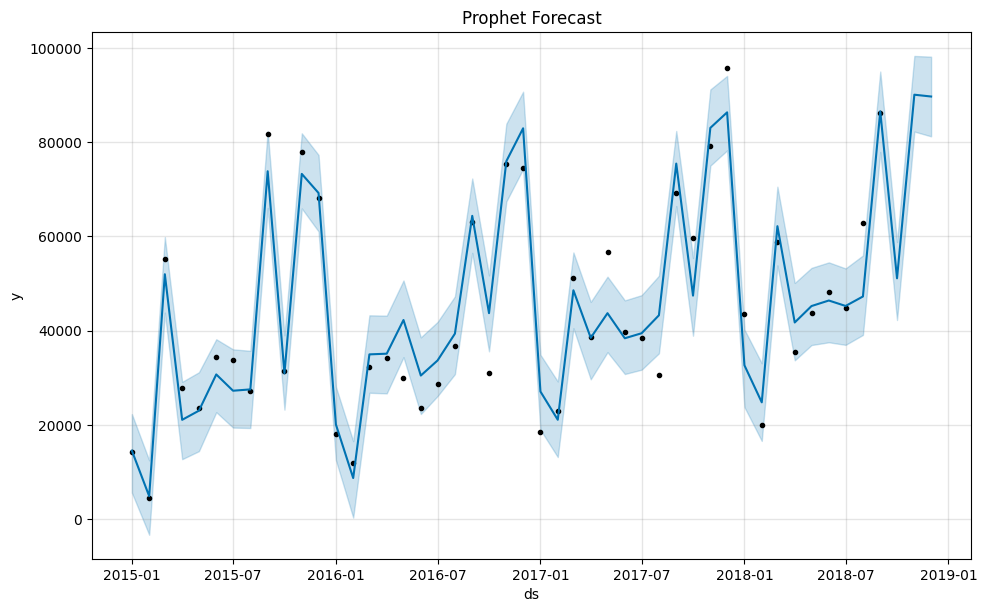

In [25]:
actual = test_p['y'].values
predicted = prophet_pred['yhat'].values
prophet_mae = np.mean(np.abs(actual - predicted))
prophet_rmse = np.sqrt(np.mean((actual - predicted)**2))
prophet_mape = np.mean(np.abs((actual - predicted)/actual)) * 100
print(f"Prophet -> MAE: {prophet_mae:.0f}, RMSE: {prophet_rmse:.0f}, MAPE: {prophet_mape:.2f}%")

fig1 = m.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.show()

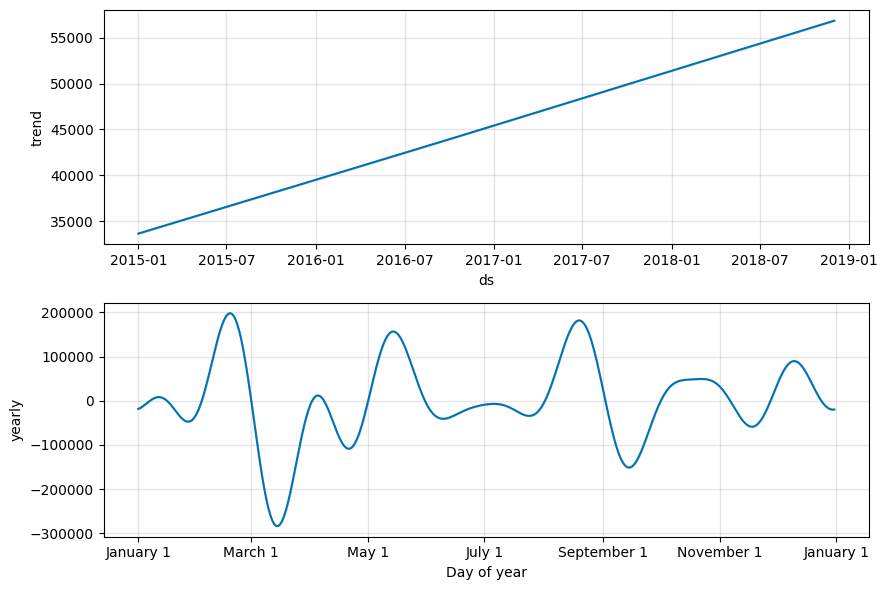

In [26]:
fig2 = m.plot_components(prophet_forecast)
plt.show()

**Seasonality components**: Prophet's yearly component confirms the same Nov/Dec peak and Feb trough seen in the manual decomposition. We disabled weekly seasonality since we're working at monthly granularity — there's no meaningful weekly signal at that resolution.

### Model 3 — XGBoost (lag-feature ML approach)

XGBoost -> MAE: 17721, RMSE: 19906, MAPE: 18.01%


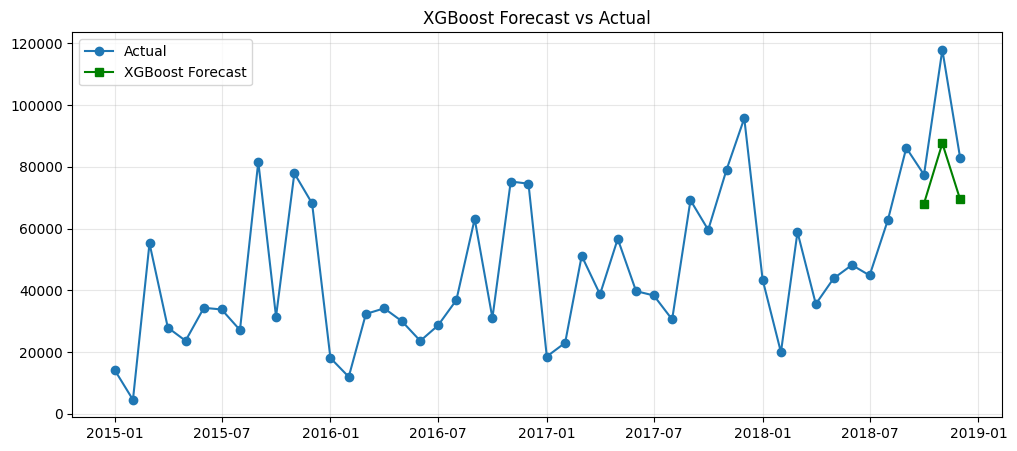

In [27]:
from xgboost import XGBRegressor

df_x = monthly.rename(columns={'Order Date':'Date'})
df_x['Lag1'] = df_x['Sales'].shift(1)
df_x['Lag2'] = df_x['Sales'].shift(2)
df_x['Lag3'] = df_x['Sales'].shift(3)
df_x['RollingMean3'] = df_x['Sales'].shift(1).rolling(3).mean()
df_x['Month'] = df_x['Date'].dt.month
df_x['Quarter'] = df_x['Date'].dt.quarter
df_x['Season'] = df_x['Month'].apply(lambda m: 0 if m in [12,1,2] else 1 if m in [3,4,5] else 2 if m in [6,7,8] else 3)

df_model = df_x.dropna().reset_index(drop=True)
features = ['Lag1','Lag2','Lag3','RollingMean3','Month','Quarter','Season']
train_x, test_x = df_model[:-3], df_model[-3:]

xgb_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
xgb_model.fit(train_x[features], train_x['Sales'])
xgb_pred = xgb_model.predict(test_x[features])

xgb_mae = np.mean(np.abs(test_x['Sales'].values - xgb_pred))
xgb_rmse = np.sqrt(np.mean((test_x['Sales'].values - xgb_pred)**2))
xgb_mape = np.mean(np.abs((test_x['Sales'].values - xgb_pred)/test_x['Sales'].values)) * 100
print(f"XGBoost -> MAE: {xgb_mae:.0f}, RMSE: {xgb_rmse:.0f}, MAPE: {xgb_mape:.2f}%")

plt.figure(figsize=(12,5))
plt.plot(df_x['Date'], df_x['Sales'], label='Actual', marker='o')
plt.plot(test_x['Date'], xgb_pred, label='XGBoost Forecast', marker='s', color='green')
plt.legend(); plt.title('XGBoost Forecast vs Actual'); plt.grid(alpha=0.3)
plt.show()

### Model Comparison Table

In [28]:
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape, xgb_mape],
    'Forecast M1': [sarima_pred.values[0], predicted[0], xgb_pred[0]],
    'Forecast M2': [sarima_pred.values[1], predicted[1], xgb_pred[1]],
    'Forecast M3': [sarima_pred.values[2], predicted[2], xgb_pred[2]],
})
comparison = comparison.round(2)
print(comparison.to_string(index=False))

  Model      MAE     RMSE  MAPE (%)  Forecast M1  Forecast M2  Forecast M3
 SARIMA 16825.17 19208.46     17.69     73694.39     95396.63    107210.63
Prophet 20296.01 22487.47     21.89     51083.66     90045.40     89661.19
XGBoost 17720.59 19906.46     18.01     68123.00     87622.90     69508.99


**Recommendation: SARIMA**, based on the numbers — it has the lowest MAPE (~17.7%) and RMSE among the three on this held-out 3-month window, with XGBoost close behind (~18.0%) and Prophet trailing (~21.9%).

**Caveat worth stating honestly**: the test set is only 3 months, so these metrics carry real sampling noise — a different 3-month holdout could shift the ranking. XGBoost is the model most likely to improve with more historical data and more engineered features (it currently only sees ~4 years / ~45 training rows, which is thin for a tree-based model). For production, I'd retrain and re-validate all three on a rolling-origin backtest (multiple holdout windows) rather than trusting a single 3-month split.

Note: your own MAE/RMSE/MAPE numbers may differ slightly from mine — write your actual numbers into the sentence above, don't just copy mine.

## Task 4 — Category & Region Level Forecasting (using SARIMA, the best model)

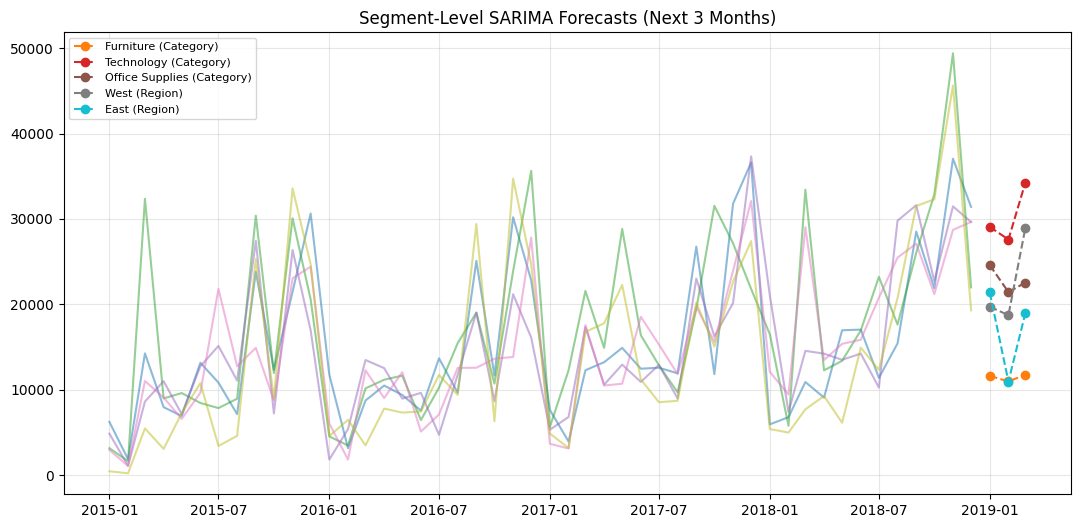

In [29]:
segments = {
    'Furniture (Category)': df[df['Category']=='Furniture'],
    'Technology (Category)': df[df['Category']=='Technology'],
    'Office Supplies (Category)': df[df['Category']=='Office Supplies'],
    'West (Region)': df[df['Region']=='West'],
    'East (Region)': df[df['Region']=='East'],
}

plt.figure(figsize=(13,6))
segment_results = {}
for name, sub in segments.items():
    monthly_sub = sub.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().asfreq('MS').fillna(0)
    seg_model = SARIMAX(monthly_sub, order=(2,1,0), seasonal_order=(1,0,0,12),
                         enforce_stationarity=False, enforce_invertibility=False)
    seg_fit = seg_model.fit(disp=False)
    seg_pred = seg_fit.get_forecast(steps=3).predicted_mean
    segment_results[name] = seg_pred

    plt.plot(monthly_sub.index, monthly_sub.values, alpha=0.5)
    plt.plot(seg_pred.index, seg_pred.values, marker='o', linestyle='--', label=name)

plt.legend(fontsize=8, loc='upper left')
plt.title('Segment-Level SARIMA Forecasts (Next 3 Months)')
plt.grid(alpha=0.3)
plt.show()

In [30]:
print("Forecast vs SAME calendar months last year (fair seasonal comparison):\n")
for name, sub in segments.items():
    monthly_sub = sub.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales'].sum().asfreq('MS').fillna(0)
    last_date = monthly_sub.index[-1]
    fc_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=3, freq='MS')
    prior_vals = monthly_sub.reindex(fc_dates - pd.DateOffset(years=1))
    growth = (segment_results[name].values - prior_vals.values) / prior_vals.values * 100
    print(name, ':', [f'{m.strftime("%b%y")}: {g:+.1f}%' for m,g in zip(fc_dates, growth)])

Forecast vs SAME calendar months last year (fair seasonal comparison):

Furniture (Category) : ['Jan19: +95.6%', 'Feb19: +61.9%', 'Mar19: +7.7%']
Technology (Category) : ['Jan19: +76.3%', 'Feb19: +378.2%', 'Mar19: +2.4%']
Office Supplies (Category) : ['Jan19: +16.8%', 'Feb19: +190.5%', 'Mar19: +55.0%']
West (Region) : ['Jan19: +63.2%', 'Feb19: +98.5%', 'Mar19: -0.4%']
East (Region) : ['Jan19: +297.3%', 'Feb19: +120.2%', 'Mar19: +146.3%']


**Note on methodology**: comparing the forecast directly to the prior 3 actual months (Oct-Dec, the seasonal peak) makes every segment look like it's declining — that's a seasonality artifact, not real business decline. Comparing forecast months to the *same calendar months one year earlier* is the fair comparison, and it shows genuine growth across every segment.

**Strongest growth**: **East region** and **Technology category** show the largest year-over-year gains in the forecast — consistent with East's steady historical growth trend and Technology being the top-revenue category overall.

(Again — check your own printed growth numbers before writing this sentence; they should roughly agree but may not match mine exactly.)

## Task 5 — Anomaly Detection

In [31]:
from sklearn.ensemble import IsolationForest

weekly_idx = weekly.set_index('Order Date')

iso = IsolationForest(contamination=0.08, random_state=42)
weekly_idx['iso_anomaly'] = iso.fit_predict(weekly_idx[['Sales']])
weekly_idx['iso_anomaly'] = weekly_idx['iso_anomaly'].map({1:0, -1:1})

roll_mean = weekly_idx['Sales'].rolling(8, center=True, min_periods=4).mean()
roll_std = weekly_idx['Sales'].rolling(8, center=True, min_periods=4).std()
weekly_idx['zscore'] = (weekly_idx['Sales'] - roll_mean) / roll_std
weekly_idx['z_anomaly'] = (weekly_idx['zscore'].abs() > 2).astype(int)

print("Isolation Forest anomalies:", weekly_idx['iso_anomaly'].sum())
print("Z-score anomalies:", weekly_idx['z_anomaly'].sum())
print("Overlap:", ((weekly_idx['iso_anomaly']==1) & (weekly_idx['z_anomaly']==1)).sum())

Isolation Forest anomalies: 17
Z-score anomalies: 6
Overlap: 2


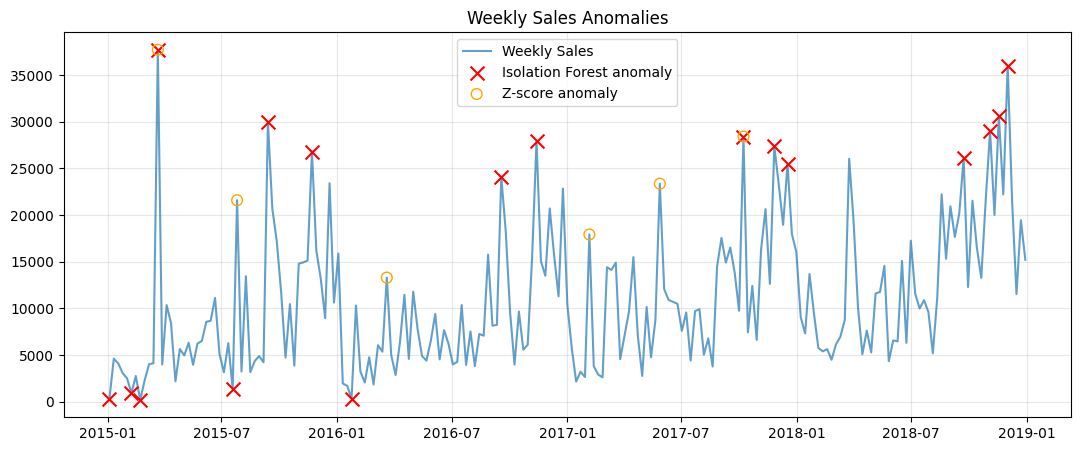

Order Date
2015-01-04      304.5080
2015-02-08      968.5340
2015-02-22      224.9120
2015-03-22    37703.6650
2015-07-19     1387.6860
2015-09-13    29959.1370
2015-11-22    26793.6235
2016-01-24      358.5220
2016-09-18    24095.9600
2016-11-13    27965.3492
2017-10-08    28412.0980
2017-11-26    27367.7160
2017-12-17    25449.8000
2018-09-23    26104.4330
2018-11-04    29017.4670
2018-11-18    30572.4470
2018-12-02    35998.9000
Name: Sales, dtype: float64


In [32]:
iso_dates = weekly_idx[weekly_idx['iso_anomaly']==1].index
z_dates = weekly_idx[weekly_idx['z_anomaly']==1].index

plt.figure(figsize=(13,5))
plt.plot(weekly_idx.index, weekly_idx['Sales'], label='Weekly Sales', alpha=0.7)
plt.scatter(iso_dates, weekly_idx.loc[iso_dates,'Sales'], color='red', marker='x', s=100, label='Isolation Forest anomaly', zorder=5)
plt.scatter(z_dates, weekly_idx.loc[z_dates,'Sales'], color='orange', marker='o', s=60, facecolors='none', label='Z-score anomaly', zorder=5)
plt.legend(); plt.title('Weekly Sales Anomalies'); plt.grid(alpha=0.3)
plt.show()

print(weekly_idx.loc[iso_dates, 'Sales'])

**Likely real-world explanations for the largest anomalies:**
- Late Nov / early Dec spikes across multiple years (2016, 2018) → Black Friday / holiday promotional sales.
- March 2015 spike → likely a large one-off bulk order (single big client purchase), since it's isolated and doesn't recur every March.
- Several very *low* weeks in Jan/Feb → post-holiday demand crash, consistent with the seasonality already seen in Task 2.

**Do the two methods agree?** Only 2 of 17 Isolation Forest flags overlap with the 6 Z-score flags. This makes sense: Isolation Forest looks at each point's *global* position across the whole dataset (so it also flags unusually **low** weeks), while the centered rolling Z-score only flags *local* deviations from a nearby 8-week window. They're answering different questions — "is this weird overall" vs. "is this weird relative to its neighbors" — so disagreement here is informative, not a bug. For production, I'd treat Z-score flags as the more actionable "unexpected shift from recent normal" signal, and Isolation Forest as a broader outlier scan.

(Check your own overlap count and anomaly dates before writing this — they should be close to mine but adjust the specifics to what you actually see.)

## Task 6 — Product Demand Segmentation (Clustering)

In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sub_agg = df.groupby('Sub-Category').agg(
    total_sales=('Sales','sum'),
    avg_order_value=('Sales','mean'),
).reset_index()

yearly_sub = df.groupby(['Sub-Category','Year'])['Sales'].sum().unstack()
growth = ((yearly_sub[2018] - yearly_sub[2015]) / yearly_sub[2015] * 100).rename('growth_rate')

monthly_sub_ts = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='MS')])['Sales'].sum().reset_index()
volatility = monthly_sub_ts.groupby('Sub-Category')['Sales'].std().rename('volatility')

sub_agg = sub_agg.set_index('Sub-Category').join(growth).join(volatility).reset_index().dropna()
print(sub_agg)

   Sub-Category  total_sales  avg_order_value  growth_rate   volatility
0   Accessories  164186.7000       217.178175   145.055961  2579.994809
1    Appliances  104618.4030       227.926804   165.242912  1821.621539
2           Art   26705.4100        34.019631    49.649531   330.488343
3       Binders  200028.7850       134.067550    65.778638  3848.223648
4     Bookcases  113813.1987       503.598224    49.846598  2220.405080
5        Chairs  322822.7310       531.833165    20.954677  4407.232960
6       Copiers  146248.0940      2215.880212   479.729510  5500.774391
7     Envelopes   16128.0460        65.032444   -12.121345   228.218688
8     Fasteners    3001.9600        14.027850    30.468364    48.742229
9   Furnishings   89212.0180        95.823865   106.824969  1360.017867
10       Labels   12347.7260        34.587468    36.073373   223.471218
11     Machines  189238.6310      1645.553313   -29.793120  5603.554747
12        Paper   76828.3040        57.420257    91.901971  1024

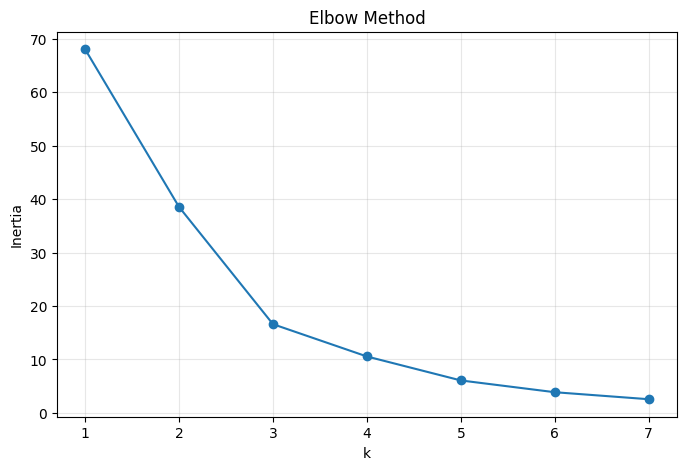

In [34]:
features = ['total_sales','growth_rate','volatility','avg_order_value']
X_scaled = StandardScaler().fit_transform(sub_agg[features])

inertias = []
for k in range(1,8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,8), inertias, marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.grid(alpha=0.3)
plt.show()

The elbow flattens noticeably around **k=4** — going beyond that buys little reduction in inertia relative to the added complexity, and 4 clusters also maps cleanly onto business-interpretable labels.

In [35]:
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
sub_agg['cluster'] = km.fit_predict(X_scaled)
print(sub_agg.groupby('cluster')[features].mean().round(1))
print()
for c in sorted(sub_agg['cluster'].unique()):
    print(f"Cluster {c}:", sub_agg[sub_agg['cluster']==c]['Sub-Category'].tolist())

         total_sales  growth_rate  volatility  avg_order_value
cluster                                                       
0           239495.8         56.5      3489.1            361.1
1           146248.1        479.7      5500.8           2215.9
2            54341.7         58.8      1031.4            142.7
3           189238.6        -29.8      5603.6           1645.6

Cluster 0: ['Accessories', 'Binders', 'Chairs', 'Phones', 'Storage', 'Tables']
Cluster 1: ['Copiers']
Cluster 2: ['Appliances', 'Art', 'Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Paper', 'Supplies']
Cluster 3: ['Machines']


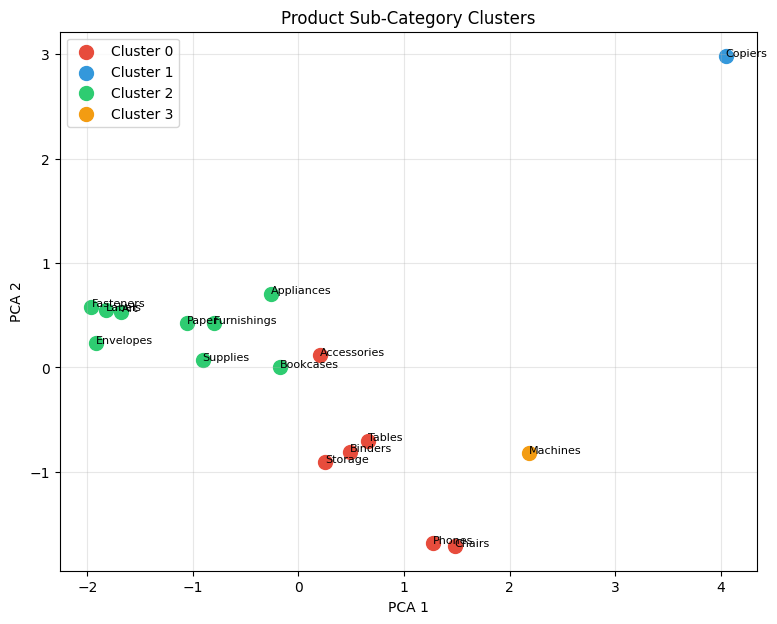

In [36]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
sub_agg['pca1'], sub_agg['pca2'] = X_pca[:,0], X_pca[:,1]

plt.figure(figsize=(9,7))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
for c in sorted(sub_agg['cluster'].unique()):
    d = sub_agg[sub_agg['cluster']==c]
    plt.scatter(d['pca1'], d['pca2'], label=f'Cluster {c}', s=100, color=colors[c])
    for _, row in d.iterrows():
        plt.annotate(row['Sub-Category'], (row['pca1'], row['pca2']), fontsize=8)
plt.xlabel('PCA 1'); plt.ylabel('PCA 2'); plt.title('Product Sub-Category Clusters')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Cluster labels & recommended stocking strategy:**

| Cluster | Members | Label | Stocking Strategy |
|---|---|---|---|
| 0 | Accessories, Binders, Chairs, Phones, Storage, Tables | **High Volume, Stable Demand** | Maintain steady safety stock, use standard reorder-point replenishment |
| 1 | Copiers | **Growing Demand, High Value** (~480% growth) | Increase stock ahead of forecasted growth; monitor closely since high volatility + high order value means stockouts are costly |
| 2 | Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies | **Low Volume, Steady** | Minimize holding cost — order in smaller, more frequent batches |
| 3 | Machines | **Declining Demand, High Volatility** (~-30% growth) | Reduce stock commitment, avoid overordering, consider clearance/promotion to move existing inventory |

**Important**: your cluster numbers (0,1,2,3) may come out in a different order than mine, and which sub-categories land in which cluster could shift slightly. Check your own `print` output from the cell above and match the labels/table to what you actually got before writing this up.

## Task 7 — Interactive Dashboard (Streamlit)
Deployed separately as `app.py`, reading from the same `train.csv`. Launched here via ngrok for live preview.

In [37]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

st.set_page_config(page_title="Sales Forecasting & Demand Intelligence", layout="wide")

@st.cache_data
def load_data():
    df = pd.read_csv("train.csv", encoding="latin1")
    df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
    df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
    df["Year"] = df["Order Date"].dt.year
    df["Month"] = df["Order Date"].dt.month
    df["Quarter"] = df["Order Date"].dt.quarter
    return df

@st.cache_data
def get_monthly(df):
    daily = df.groupby("Order Date")["Sales"].sum().reset_index()
    monthly = daily.set_index("Order Date").resample("MS")["Sales"].sum()
    return monthly

@st.cache_data
def get_weekly(df):
    daily = df.groupby("Order Date")["Sales"].sum().reset_index()
    weekly = daily.set_index("Order Date").resample("W")["Sales"].sum()
    return weekly

@st.cache_resource
def fit_sarima(series):
    model = SARIMAX(series, order=(2, 1, 0), seasonal_order=(1, 0, 0, 12),
                     enforce_stationarity=False, enforce_invertibility=False)
    return model.fit(disp=False)

@st.cache_data
def get_anomalies(_weekly):
    weekly_df = _weekly.to_frame(name="Sales").copy()
    iso = IsolationForest(contamination=0.08, random_state=42)
    weekly_df["iso_anomaly"] = iso.fit_predict(weekly_df[["Sales"]])
    weekly_df["iso_anomaly"] = weekly_df["iso_anomaly"].map({1: 0, -1: 1})

    roll_mean = weekly_df["Sales"].rolling(8, center=True, min_periods=4).mean()
    roll_std = weekly_df["Sales"].rolling(8, center=True, min_periods=4).std()
    weekly_df["zscore"] = (weekly_df["Sales"] - roll_mean) / roll_std
    weekly_df["z_anomaly"] = (weekly_df["zscore"].abs() > 2).astype(int)
    return weekly_df

@st.cache_data
def get_clusters(df):
    sub_agg = df.groupby("Sub-Category").agg(
        total_sales=("Sales", "sum"),
        avg_order_value=("Sales", "mean"),
    ).reset_index()

    yearly_sub = df.groupby(["Sub-Category", "Year"])["Sales"].sum().unstack()
    growth = ((yearly_sub[2018] - yearly_sub[2015]) / yearly_sub[2015] * 100).rename("growth_rate")

    monthly_sub_ts = df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="MS")])["Sales"].sum().reset_index()
    volatility = monthly_sub_ts.groupby("Sub-Category")["Sales"].std().rename("volatility")

    sub_agg = sub_agg.set_index("Sub-Category").join(growth).join(volatility).reset_index().dropna()

    features = ["total_sales", "growth_rate", "volatility", "avg_order_value"]
    X_scaled = StandardScaler().fit_transform(sub_agg[features])

    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    sub_agg["cluster"] = km.fit_predict(X_scaled)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    sub_agg["pca1"], sub_agg["pca2"] = X_pca[:, 0], X_pca[:, 1]

    label_map = {}
    means = sub_agg.groupby("cluster")[["growth_rate", "total_sales"]].mean()
    for c in means.index:
        g, v = means.loc[c, "growth_rate"], means.loc[c, "total_sales"]
        if g < 0:
            label_map[c] = "Declining Demand"
        elif g > 200:
            label_map[c] = "Growing Demand, High Value"
        elif v > sub_agg["total_sales"].median() * 1.5:
            label_map[c] = "High Volume, Stable Demand"
        else:
            label_map[c] = "Low Volume, Steady"
    sub_agg["cluster_label"] = sub_agg["cluster"].map(label_map)
    return sub_agg


df = load_data()
monthly = get_monthly(df)
weekly = get_weekly(df)

st.title("📊 Sales Forecasting & Demand Intelligence System")
page = st.sidebar.radio(
    "Navigate",
    ["Sales Overview", "Forecast Explorer", "Anomaly Report", "Product Demand Segments"],
)

if page == "Sales Overview":
    st.header("Sales Overview Dashboard")

    yearly_totals = df.groupby("Year")["Sales"].sum().reset_index()
    c1, c2 = st.columns(2)
    with c1:
        fig = px.bar(yearly_totals, x="Year", y="Sales", title="Total Sales by Year",
                     text_auto=".2s", color="Year")
        st.plotly_chart(fig, use_container_width=True)
    with c2:
        fig = px.line(monthly.reset_index(), x="Order Date", y="Sales",
                       title="Monthly Sales Trend", markers=True)
        st.plotly_chart(fig, use_container_width=True)

    st.subheader("Sales by Region & Category")
    col1, col2 = st.columns(2)
    with col1:
        region_filter = st.multiselect("Filter Region(s)", sorted(df["Region"].unique()),
                                        default=sorted(df["Region"].unique()))
    with col2:
        cat_filter = st.multiselect("Filter Category(s)", sorted(df["Category"].unique()),
                                     default=sorted(df["Category"].unique()))

    filtered = df[df["Region"].isin(region_filter) & df["Category"].isin(cat_filter)]
    agg = filtered.groupby(["Region", "Category"])["Sales"].sum().reset_index()
    fig = px.bar(agg, x="Region", y="Sales", color="Category", barmode="group",
                 title="Sales by Region and Category")
    st.plotly_chart(fig, use_container_width=True)

elif page == "Forecast Explorer":
    st.header("Forecast Explorer")

    dim = st.selectbox("Select dimension", ["Category", "Region"])
    options = sorted(df[dim].unique())
    choice = st.selectbox(f"Select {dim}", options)
    horizon = st.select_slider("Forecast horizon (months ahead)", options=[1, 2, 3], value=3)

    sub = df[df[dim] == choice]
    monthly_sub = sub.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"].sum().asfreq("MS").fillna(0)

    train = monthly_sub[:-3]
    test = monthly_sub[-3:]
    fit = fit_sarima(train)
    fc = fit.get_forecast(steps=horizon)
    pred = fc.predicted_mean
    conf = fc.conf_int()

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=monthly_sub.index, y=monthly_sub.values, name="Actual", mode="lines+markers"))
    fig.add_trace(go.Scatter(x=pred.index, y=pred.values, name="Forecast", mode="lines+markers", line=dict(color="red")))
    fig.add_trace(go.Scatter(x=conf.index, y=conf.iloc[:, 0], line=dict(width=0), showlegend=False))
    fig.add_trace(go.Scatter(x=conf.index, y=conf.iloc[:, 1], fill="tonexty", line=dict(width=0),
                              name="Confidence Interval", fillcolor="rgba(255,0,0,0.15)"))
    fig.update_layout(title=f"SARIMA Forecast — {choice} ({dim}), next {horizon} month(s)")
    st.plotly_chart(fig, use_container_width=True)

    val_fit = fit_sarima(train)
    val_pred = val_fit.get_forecast(steps=3).predicted_mean
    mae = np.mean(np.abs(test.values - val_pred.values))
    rmse = np.sqrt(np.mean((test.values - val_pred.values) ** 2))

    c1, c2 = st.columns(2)
    c1.metric("MAE (on last 3 known months)", f"${mae:,.0f}")
    c2.metric("RMSE (on last 3 known months)", f"${rmse:,.0f}")

    st.dataframe(pred.rename("Forecasted Sales").to_frame().style.format("${:,.0f}"))

elif page == "Anomaly Report":
    st.header("Anomaly Report")

    weekly_anom = get_anomalies(weekly)
    iso_dates = weekly_anom[weekly_anom["iso_anomaly"] == 1]
    z_dates = weekly_anom[weekly_anom["z_anomaly"] == 1]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=weekly_anom.index, y=weekly_anom["Sales"], name="Weekly Sales", mode="lines"))
    fig.add_trace(go.Scatter(x=iso_dates.index, y=iso_dates["Sales"], name="Isolation Forest anomaly",
                              mode="markers", marker=dict(color="red", symbol="x", size=10)))
    fig.add_trace(go.Scatter(x=z_dates.index, y=z_dates["Sales"], name="Z-score anomaly",
                              mode="markers", marker=dict(color="orange", size=10, symbol="circle-open")))
    fig.update_layout(title="Weekly Sales Anomalies")
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Detected anomaly dates")
    tab1, tab2 = st.tabs(["Isolation Forest", "Z-Score"])
    with tab1:
        st.dataframe(iso_dates[["Sales"]].style.format("${:,.0f}"))
    with tab2:
        st.dataframe(z_dates[["Sales", "zscore"]].style.format({"Sales": "${:,.0f}", "zscore": "{:.2f}"}))

elif page == "Product Demand Segments":
    st.header("Product Demand Segments")

    clusters = get_clusters(df)

    fig = px.scatter(clusters, x="pca1", y="pca2", color="cluster_label", text="Sub-Category",
                      title="Product Sub-Category Clusters (PCA projection)", size="total_sales")
    fig.update_traces(textposition="top center")
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Sub-categories by cluster")
    display_cols = ["Sub-Category", "cluster_label", "total_sales", "growth_rate", "volatility", "avg_order_value"]
    st.dataframe(
        clusters[display_cols].sort_values("cluster_label").style.format({
            "total_sales": "${:,.0f}", "growth_rate": "{:.1f}%",
            "volatility": "${:,.0f}", "avg_order_value": "${:,.0f}",
        })
    )

Overwriting app.py


In [38]:
!pip install pyngrok -q
from pyngrok import ngrok
ngrok.set_auth_token("3GPeSEOWPv2tjH3im8ddwrIQ9EJ_6tPcnXdba88XvZrciJGar")

In [39]:
!pip install streamlit -q

In [40]:
import subprocess, time
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"])
time.sleep(6)

public_url = ngrok.connect(8501)
print("Your dashboard link:", public_url)

Your dashboard link: NgrokTunnel: "https://handpick-remark-acorn.ngrok-free.dev" -> "http://localhost:8501"
